## Test preprocessing

Ce notebook teste l'intégrité des données générée par le processus de preprocess/indexation

In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.optional.development.dataset import IndexedDataset

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
dataset_train = IndexedDataset.create(config, DatasetType.TRAIN)
dataset_test = IndexedDataset.create(config, DatasetType.TEST)
dataset_validation = IndexedDataset.create(config, DatasetType.VALIDATION)

In [5]:
# validation quantite de labels
assert len(dataset_train.species_label) == 5
assert len(dataset_test.species_label) == 5
assert len(dataset_validation.species_label) == 5

In [6]:
# inspection visuelle
print(dataset_train.species_label)
print(len(dataset_train.species_label))

['Barn Swallow', 'Common Buzzard', 'Western Yellow Wagtail', 'Thrush Nightingale', 'Willow Warbler']
5


In [7]:
group_length, segment_length_, group_hop_length = config.preprocess.group_frame_infos()
print(group_length, segment_length_, group_hop_length)

60 30 15


In [8]:
# train
print(dataset_train.spectrogram_groups.shape)
print("min:", np.min(dataset_train.spectrogram_groups), ", max:", np.max(dataset_train.spectrogram_groups))

print()

print(dataset_train.spectrogram_mask_groups.shape)
print("min:", np.min(dataset_train.spectrogram_mask_groups), ", max:", np.max(dataset_train.spectrogram_mask_groups))

print()

print(dataset_train.y.shape)
print(dataset_train.y[:5])

num_samples, group_segment_count, n_mels, segment_length = dataset_train.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_train_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_train.lat_long.shape == (num_samples, 2)

np.unique( dataset_train.y )

(4116, 3, 128, 30)
min: -1.0 , max: 6.244573e-08

(4116, 3, 30)
min: 0 , max: 1

(4116, 5)
[[0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]]


array([0, 1], dtype=int16)

In [9]:
# test
print(dataset_test.spectrogram_groups.shape)
print("min:", np.min(dataset_test.spectrogram_groups), ", max:", np.max(dataset_test.spectrogram_groups))

print()

print(dataset_test.spectrogram_mask_groups.shape)
print("min:", np.min(dataset_test.spectrogram_mask_groups), ", max:", np.max(dataset_test.spectrogram_mask_groups))

print()

print(dataset_test.y.shape)
print(dataset_test.y[:3])

num_samples, group_segment_count, n_mels, segment_length = dataset_test.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * config.preprocess.split_test_size
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_test.lat_long.shape == (num_samples, 2)

np.unique( dataset_test.y )

(1372, 3, 128, 30)
min: -1.0 , max: 5.4120964e-08

(1372, 3, 30)
min: 0 , max: 1

(1372, 5)
[[0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 1 0]]


array([0, 1], dtype=int16)

In [10]:
# validation
print(dataset_validation.spectrogram_groups.shape)
print("min:", np.min(dataset_validation.spectrogram_groups), ", max:", np.max(dataset_validation.spectrogram_groups))

print()

print(dataset_validation.spectrogram_mask_groups.shape)
print("min:", np.min(dataset_validation.spectrogram_mask_groups), ", max:", np.max(dataset_validation.spectrogram_mask_groups))

print()

print(dataset_validation.y.shape)
print(dataset_validation.y[:5])

num_samples, group_segment_count, n_mels, segment_length = dataset_validation.spectrogram_groups.shape
assert num_samples == config.preprocess.group_count * 5 * (1 - config.preprocess.split_train_size - config.preprocess.split_test_size)
assert group_segment_count == config.preprocess.group_segment_count
assert n_mels == config.preprocess.spectrogram_n_mels
assert segment_length == segment_length_

assert dataset_validation.lat_long.shape == (num_samples, 2)

np.unique( dataset_validation.y )

(1372, 3, 128, 30)
min: -1.0 , max: 8.254859e-08

(1372, 3, 30)
min: 0 , max: 1

(1372, 5)
[[0 0 0 1 0]
 [0 1 0 0 0]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]]


array([0, 1], dtype=int16)

In [11]:
# validation distribution especes
print( np.sum( dataset_train.y, axis=0 ) / dataset_train.y.shape[0] )
print( np.sum( dataset_test.y, axis=0 ) / dataset_test.y.shape[0] )
print( np.sum( dataset_validation.y, axis=0 ) / dataset_validation.y.shape[0] )

[0.19995141 0.20019436 0.19995141 0.19995141 0.19995141]
[0.20043732 0.19970845 0.19970845 0.19970845 0.20043732]
[0.19970845 0.19970845 0.20043732 0.20043732 0.19970845]


In [63]:
import librosa as rosa
import matplotlib.ticker as mticker

from ffury.optional.development.misc.hdf5 import open_file
from ffury.optional.development.transforms.properties import (
    _SPECTROGRAM,
    _SPECTROGRAM_MASK
)

def colorize_mask(mask, height):
    # appliquer couleur au masque
    image = np.zeros( (mask.shape[0], 3) )

    image[mask == 0] = [1, 0, 0]
    image[mask != 0] = [0, 1, 0]

    # convertir en image avec bonne resolution
    image = image[np.newaxis, ...]
    return np.tile(image, (height, 1, 1))

def specshow(data, data_mask=None, data_mask_alpha=0.1, start_index=0):
    if False:
        rosa.display.specshow(data,
                              x_axis='time',
                              y_axis='mel',
                              sr=config.preprocess.clip_sampling_rate_hz,
                              ax=plt.gca(),
                              n_fft=config.preprocess.spectrogram_n_ftt,
                              hop_length=config.preprocess.spectrogram_hop_length,
                              cmap="gray_r")
    else:
        if not start_index is None:
            def update_ticks(x, loc):
                return x + start_index

            plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(update_ticks))

        plt.gca().imshow(data,
                         cmap="gray",
                         aspect="auto",
                         interpolation="nearest",
                         vmin=-1, # spectrogram a un range [0, -1]
                         vmax=0)

        if not data_mask is None:
            mask = colorize_mask(data_mask, data.shape[0])
            plt.gca().imshow(mask,
                             aspect="auto",
                             interpolation="nearest",
                             alpha=data_mask_alpha)

def plot_group(path, start, stop, data_mask_alpha=0.1):
    with open_file(path, "r") as file:
        spectrogram_data = file[_SPECTROGRAM]
        spectrogram_mask_data = file[_SPECTROGRAM_MASK]

        fig = plt.figure(figsize=(12, 2.5))

        specshow(spectrogram_data[:, start:stop],
                 spectrogram_mask_data[start:stop],
                 data_mask_alpha)

        plt.title(f"Group {path.name}, ({start}, {stop})")
        plt.tight_layout()
        plt.show()

def plot_segments(data, data_mask, data_mask_alpha=0.1):
    assert data.shape[0] == data_mask.shape[0]
    assert data.shape[2] == data_mask.shape[1]

    _, _, segment_hop = config.preprocess.group_frame_infos()

    fig = plt.figure(figsize=(12, 2.5))

    num_segments = data.shape[0]
    for s in range(num_segments):
        subplot = f"1{num_segments}{s + 1}"
        plt.subplot(int(subplot))
        specshow(data[s], data_mask[s], data_mask_alpha, s * segment_hop)

    plt.suptitle("Segments")
    plt.tight_layout()
    plt.show()

def validate_data(path, start, stop, data, data_mask):
    _, group_length, segment_hop = config.preprocess.group_frame_infos()

    assert data.shape[2] == group_length
    assert data_mask.shape[1] == group_length

    with open_file(path, "r") as file:
        spectrogram_data = file[_SPECTROGRAM][:, start:stop]
        spectrogram_mask_data = file[_SPECTROGRAM_MASK][start:stop]

        for segment, segment_mask, start in zip(data, data_mask, range(0, len(spectrogram_data), segment_hop)):
            group_data = spectrogram_data[:, start:start + data.shape[2]]
            group_mask_data = spectrogram_mask_data[start:start + data.shape[2]]

            assert np.allclose(group_data, segment)
            assert np.allclose(group_mask_data, segment_mask)

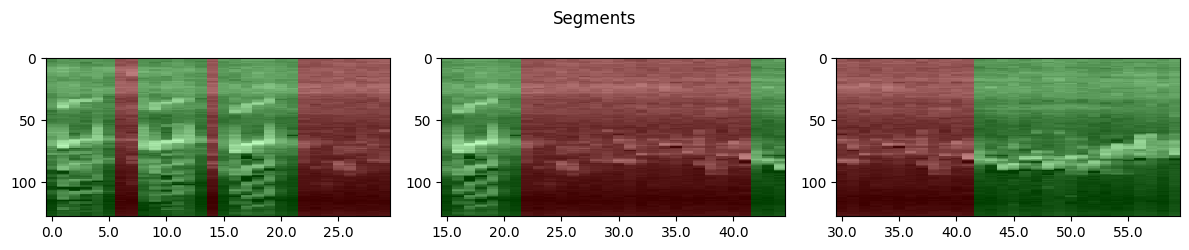

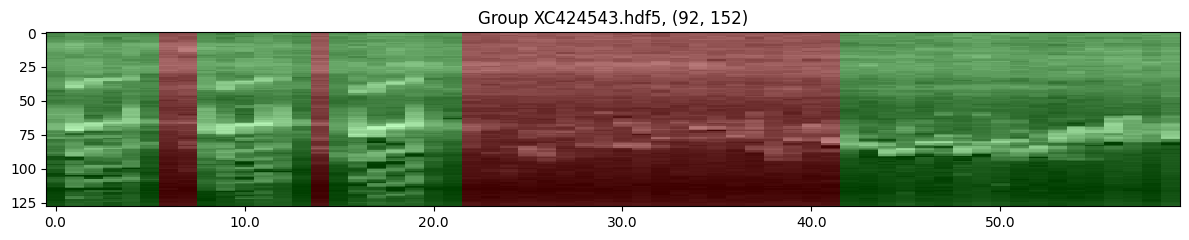

In [65]:
# visualiser les groupes, segments et masque
# note ; si l'indexation change, ces infos doivent changer aussi. Utiliser --log-debug-info

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_validation.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/eaywag1/XC571900.hdf5, 1371, 0, (40, 70)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/eaywag1/XC571900.hdf5, 1371, 1, (55, 85)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/eaywag1/XC571900.hdf5, 1371, 2, (70, 100)

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_validation.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/thrnig1/XC728590.hdf5, 1294, 0, (770, 800)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/thrnig1/XC728590.hdf5, 1294, 1, (785, 815)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/thrnig1/XC728590.hdf5, 1294, 2, (800, 830)

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_train.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC744642.hdf5, 910, 0, (101, 131)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC744642.hdf5, 910, 1, (116, 146)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC744642.hdf5, 910, 2, (131, 161

# Dst: /Users/jfgagnon/Projects/FeatheredFury/build/data_train.hdf5
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/combuz1/XC424543.hdf5, 1952, 0, (92, 122)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/combuz1/XC424543.hdf5, 1952, 1, (107, 137)
#     /Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/combuz1/XC424543.hdf5, 1952, 2, (122, 152)

DATASET = dataset_train
GROUP_INDEX = 1952
GROUP_BEGIN = 92
GROUP_END = 152
FILENAME = "combuz1/XC424543.hdf5"
MASK_ALPHA = 0.25

# validation data
validate_data(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, FILENAME),
              GROUP_BEGIN,
              GROUP_END,
              DATASET.spectrogram_groups[GROUP_INDEX],
              DATASET.spectrogram_mask_groups[GROUP_INDEX])

# visualisation
plot_segments(DATASET.spectrogram_groups[GROUP_INDEX],
              DATASET.spectrogram_mask_groups[GROUP_INDEX],
              MASK_ALPHA)
plot_group(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, FILENAME),
           GROUP_BEGIN,
           GROUP_END,
           MASK_ALPHA)

In [14]:
assert dataset_validation.spectrogram_groups.is_virtual

print(dataset_validation.spectrogram_groups[0, 0].shape, config.preprocess.clip_sampling_rate_hz)
print()
print( config.preprocess.group_frame_infos() )
print( config.preprocess.group_ms_infos() )
print()

(128, 30) 22050

(60, 30, 15)
(6000, 3000, 1500)

